In [ ]:
*********** Mnist - logistic - handwritten - datset *******************

In [1]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader , random_split 


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
dataset = MNIST(root = 'data/',download = True)

In [4]:
len(dataset)

60000

In [5]:
test_dataset = MNIST(root = 'data/',train = False)

In [6]:
len(test_dataset)

10000

Label:  5


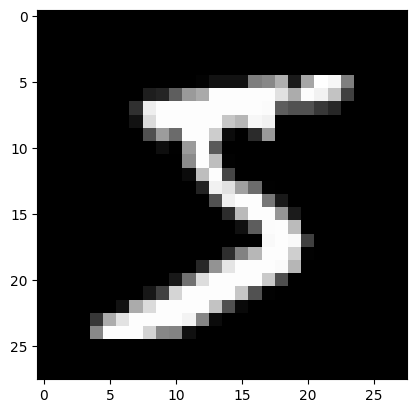

In [7]:
img , label = dataset[0]
plt.imshow(img , cmap = "grey")
print("Label: ",label)

Label:  3


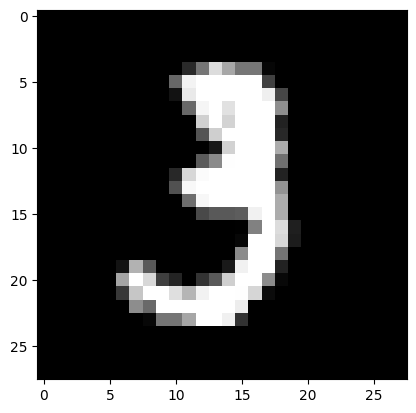

In [8]:
img , label = dataset[10]
plt.imshow(img , cmap = "grey")
print("Label: ",label)

Label:  1


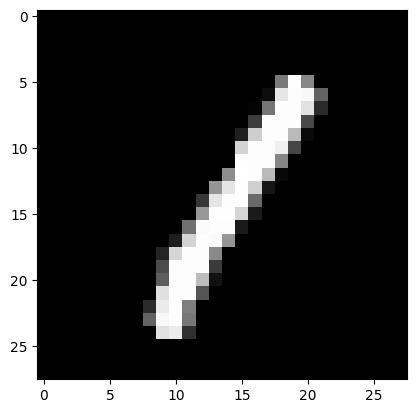

In [9]:
img , label = dataset[23]
plt.imshow(img , cmap = "grey")
print("Label: ",label)

In [10]:
dataset = MNIST(root = 'data/',train = True , transform = transforms.ToTensor())

Label:  5


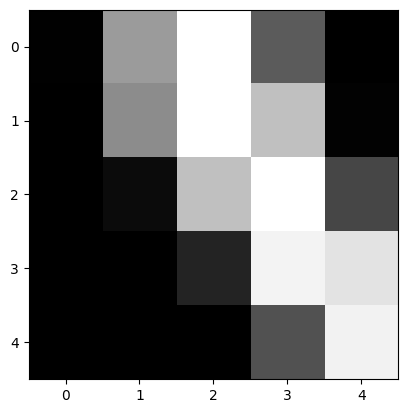

In [11]:
img_tensor ,label =  dataset[0]
plt.imshow(img_tensor[0,10:15,10:15] , cmap='grey')
print("Label: ",label)

Label:  0


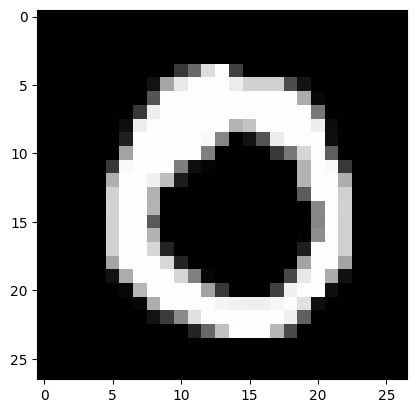

In [12]:
img_tensor ,label =  dataset[56]
plt.imshow(img_tensor[0,1:28,1:28] , cmap='grey')
print("Label: ",label)

In [13]:
maxs ,mins = torch.max(img_tensor) ,torch.min(img_tensor)
print(maxs)
print(mins)

tensor(1.)
tensor(0.)


In [14]:
test_dataset = MNIST(root = 'data/',train = False ,transform = transforms.ToTensor())

In [15]:
train_ds , val_ds = random_split(dataset , [50000,10000])


In [16]:
print(len(train_ds))
print(len(val_ds))

50000
10000


In [17]:
train_loader = DataLoader(train_ds , batch_size = 128 , shuffle = True)

In [18]:
val_loader = DataLoader(val_ds , batch_size = 128)

In [19]:
input_size = 28*28*1 
num_class = 10 # from 0 to 9
model = nn.Linear(input_size , num_class)
print(model.weight)
print(model.bias)

Parameter containing:
tensor([[-0.0178,  0.0257,  0.0319,  ..., -0.0036, -0.0027,  0.0095],
        [-0.0202, -0.0061, -0.0038,  ..., -0.0143,  0.0333, -0.0010],
        [-0.0252,  0.0079,  0.0018,  ..., -0.0213, -0.0289, -0.0114],
        ...,
        [ 0.0116, -0.0140,  0.0149,  ...,  0.0056, -0.0263,  0.0123],
        [-0.0017,  0.0350, -0.0112,  ...,  0.0158, -0.0137,  0.0340],
        [-0.0024,  0.0012, -0.0348,  ...,  0.0156, -0.0044, -0.0071]],
       requires_grad=True)
Parameter containing:
tensor([-0.0334, -0.0312,  0.0336, -0.0043, -0.0093,  0.0350, -0.0289, -0.0156,
        -0.0071, -0.0039], requires_grad=True)


In [20]:
for image , label in train_loader:
    print(image.shape)
    print(label)
    preds = model(image)
    break
# this is not possible because the nn.Linear model expect the input_size to be a 2 - dimentional array not a 4 - dimentional array .so replace is needed

torch.Size([128, 1, 28, 28])
tensor([8, 2, 1, 6, 7, 5, 5, 0, 7, 1, 3, 8, 4, 4, 9, 2, 3, 7, 1, 1, 6, 0, 8, 0,
        5, 9, 0, 7, 2, 2, 8, 2, 3, 6, 9, 6, 3, 5, 6, 2, 6, 6, 7, 6, 9, 6, 0, 3,
        1, 2, 9, 4, 6, 1, 0, 3, 3, 9, 2, 4, 9, 5, 4, 7, 3, 3, 0, 5, 4, 7, 8, 9,
        0, 2, 0, 3, 9, 6, 5, 6, 5, 9, 4, 7, 2, 4, 8, 6, 1, 4, 6, 8, 3, 3, 8, 8,
        1, 4, 3, 7, 6, 3, 4, 4, 9, 8, 3, 6, 2, 4, 1, 4, 2, 3, 1, 4, 2, 2, 9, 9,
        0, 7, 2, 8, 7, 6, 0, 9])


RuntimeError: mat1 and mat2 shapes cannot be multiplied (3584x28 and 784x10)

In [21]:
28*28

784

In [22]:
class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size,num_class)
    def forward(self,xb):
        xb = xb.reshape(-1,784)
        out = self.linear(xb)
        return out
model = MNISTModel()        

In [23]:
print(model.linear.weight.shape)
print(model.linear.bias)

torch.Size([10, 784])
Parameter containing:
tensor([-0.0341,  0.0013, -0.0320, -0.0019, -0.0027, -0.0054,  0.0290, -0.0219,
         0.0106, -0.0346], requires_grad=True)


In [24]:
len(train_ds)

50000

In [25]:
for image , label in train_loader:
    print(image.shape)
    print(label)
    preds = model(image)
    break

torch.Size([128, 1, 28, 28])
tensor([7, 8, 7, 3, 3, 1, 7, 7, 1, 8, 5, 0, 5, 4, 3, 3, 9, 2, 8, 0, 6, 1, 5, 1,
        6, 4, 2, 0, 9, 0, 6, 8, 7, 3, 0, 4, 1, 1, 6, 0, 5, 2, 3, 1, 7, 9, 2, 6,
        7, 5, 7, 2, 5, 5, 6, 9, 4, 3, 1, 1, 0, 6, 3, 0, 8, 4, 9, 5, 5, 9, 0, 2,
        0, 5, 7, 6, 3, 5, 8, 5, 3, 6, 6, 0, 2, 3, 4, 0, 6, 7, 7, 2, 5, 9, 2, 0,
        0, 1, 2, 2, 9, 7, 7, 3, 3, 3, 4, 3, 1, 6, 1, 8, 3, 2, 1, 4, 6, 1, 5, 5,
        5, 1, 7, 2, 4, 4, 0, 8])


In [26]:
print("Sample Prediction: ",preds[0:2].data)

Sample Prediction:  tensor([[ 0.0497,  0.0524, -0.3112, -0.1517,  0.1441, -0.2293,  0.3116,  0.0750,
         -0.0113, -0.1893],
        [ 0.3864, -0.1742, -0.0562, -0.3529,  0.0066, -0.3082,  0.2321, -0.1678,
         -0.1425,  0.1330]])


In [27]:
probs = F.softmax(preds , dim = 1)
#looking the Sample of the Probability
print("Sample Output: ",probs[0:3].data)
#sum of probability is equal to 1
print("Sum: ",torch.sum(probs[0]).item())

Sample Output:  tensor([[0.1061, 0.1064, 0.0739, 0.0867, 0.1166, 0.0803, 0.1379, 0.1088, 0.0998,
         0.0835],
        [0.1499, 0.0856, 0.0963, 0.0716, 0.1025, 0.0748, 0.1285, 0.0861, 0.0883,
         0.1163],
        [0.1230, 0.0911, 0.0854, 0.1069, 0.1142, 0.0659, 0.1288, 0.1130, 0.0915,
         0.0800]])
Sum:  1.0


In [28]:
max , preds = torch.max(probs, dim = 1)
print(preds)

tensor([6, 0, 6, 6, 4, 6, 0, 7, 6, 7, 7, 0, 7, 7, 7, 7, 7, 9, 0, 5, 9, 6, 7, 8,
        3, 6, 6, 8, 7, 7, 7, 6, 7, 6, 7, 6, 6, 4, 4, 6, 9, 7, 7, 6, 6, 9, 0, 7,
        6, 8, 7, 0, 6, 6, 4, 4, 7, 7, 6, 6, 7, 6, 6, 7, 6, 6, 6, 7, 9, 0, 4, 6,
        4, 0, 6, 7, 6, 4, 6, 4, 6, 7, 0, 4, 6, 9, 6, 0, 6, 4, 6, 6, 6, 7, 6, 1,
        4, 6, 6, 9, 7, 6, 8, 9, 9, 4, 6, 7, 4, 7, 4, 6, 6, 6, 6, 6, 6, 4, 4, 7,
        4, 7, 6, 6, 7, 7, 6, 6])


In [29]:
print(len(label))

128


In [30]:
def accuracy(output , label):
    _,preds = torch.max(output , dim = 1)
    return torch.tensor(torch.sum(preds == label).item()/len(preds))

In [31]:
accuracy(probs , label)

tensor(0.0703)

In [32]:
len(preds)

128

In [33]:
len(label)

128

In [34]:
loss_fn = F.cross_entropy
loss = loss_fn(model(image) ,label)
print(loss)

tensor(2.3389, grad_fn=<NllLossBackward0>)


In [35]:
#opt = torch.optim.SGD(model.parameters(),lr = 1e-4)

In [36]:
def fit(epochs, lr, model, train_loader, val_loader, opt_func=torch.optim.SGD):
    optimizer = opt_func(model.parameters(), lr)
    history = [] # for recording epoch-wise results
    
    for epoch in range(epochs):
        
        # Training Phase 
        for batch in train_loader:
            loss = model.training_step(batch)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        
        # Validation phase
        result = evaluate(model, val_loader)
        model.epoch_end(epoch, result)
        history.append(result)

    return history

In [37]:
def evaluate(model,val_loader):
    output = [model.validation_step(batch) for batch in val_loader]
    return model.validation_epoch_end(output)
    

In [38]:
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(input_size, num_class)
        
    def forward(self, xb):
        xb = xb.reshape(-1, 784)
        out = self.linear(xb)
        return out
    
    def training_step(self, batch):
        images, labels = batch 
        out = self(images)                  # Generate predictions
        loss = F.cross_entropy(out, labels) # Calculate loss
        return loss
    
    def validation_step(self, batch):
        images, labels = batch 
        out = self(images)                    # Generate predictions
        loss = F.cross_entropy(out, labels)   # Calculate loss
        acc = accuracy(out, labels)           # Calculate accuracy
        return {'val_loss': loss, 'val_acc': acc}
        
    def validation_epoch_end(self, outputs):
        batch_losses = [x['val_loss'] for x in outputs]
        epoch_loss = torch.stack(batch_losses).mean()   # Combine losses
        batch_accs = [x['val_acc'] for x in outputs]
        epoch_acc = torch.stack(batch_accs).mean()      # Combine accuracies
        return {'val_loss': epoch_loss.item(), 'val_acc': epoch_acc.item()}
    
    def epoch_end(self, epoch, result):
        print("Epoch [{}], val_loss: {:.4f}, val_acc: {:.4f}".format(epoch, result['val_loss'], result['val_acc']))
    
model = MnistModel()

In [39]:
result0 = evaluate(model , val_loader)
print(result0)

{'val_loss': 2.307854652404785, 'val_acc': 0.09414556622505188}


In [40]:
history1 = fit(5,0.0005,model,train_loader, val_loader)
print(history1)

Epoch [0], val_loss: 2.1024, val_acc: 0.4589
Epoch [1], val_loss: 1.9359, val_acc: 0.6110
Epoch [2], val_loss: 1.7939, val_acc: 0.6776
Epoch [3], val_loss: 1.6716, val_acc: 0.7162
Epoch [4], val_loss: 1.5658, val_acc: 0.7432
[{'val_loss': 2.102445363998413, 'val_acc': 0.45886075496673584}, {'val_loss': 1.9358974695205688, 'val_acc': 0.6109572649002075}, {'val_loss': 1.7939397096633911, 'val_acc': 0.6776107549667358}, {'val_loss': 1.6715848445892334, 'val_acc': 0.7161787748336792}, {'val_loss': 1.5657845735549927, 'val_acc': 0.7431764006614685}]


In [41]:
history2 = fit(5,0.0005,model,train_loader, val_loader)

Epoch [0], val_loss: 1.4740, val_acc: 0.7598
Epoch [1], val_loss: 1.3942, val_acc: 0.7728
Epoch [2], val_loss: 1.3244, val_acc: 0.7845
Epoch [3], val_loss: 1.2631, val_acc: 0.7918
Epoch [4], val_loss: 1.2091, val_acc: 0.7984


In [42]:
history3 = fit(5,0.0008,model,train_loader, val_loader)

Epoch [0], val_loss: 1.1349, val_acc: 0.8059
Epoch [1], val_loss: 1.0728, val_acc: 0.8127
Epoch [2], val_loss: 1.0202, val_acc: 0.8189
Epoch [3], val_loss: 0.9752, val_acc: 0.8236
Epoch [4], val_loss: 0.9362, val_acc: 0.8274


In [43]:
history4 = fit(5,0.0008 , model,train_loader, val_loader)

Epoch [0], val_loss: 0.9021, val_acc: 0.8311
Epoch [1], val_loss: 0.8720, val_acc: 0.8346
Epoch [2], val_loss: 0.8453, val_acc: 0.8362
Epoch [3], val_loss: 0.8213, val_acc: 0.8387
Epoch [4], val_loss: 0.7998, val_acc: 0.8409


In [44]:
history5 = fit(5,0.0007 , model,train_loader, val_loader)

Epoch [0], val_loss: 0.7826, val_acc: 0.8424
Epoch [1], val_loss: 0.7668, val_acc: 0.8446
Epoch [2], val_loss: 0.7522, val_acc: 0.8453
Epoch [3], val_loss: 0.7387, val_acc: 0.8466
Epoch [4], val_loss: 0.7261, val_acc: 0.8481


In [45]:
history = history1 + history2 + history3 + history4 + history5

In [46]:
accuracy = [result['val_acc'] for result in history]

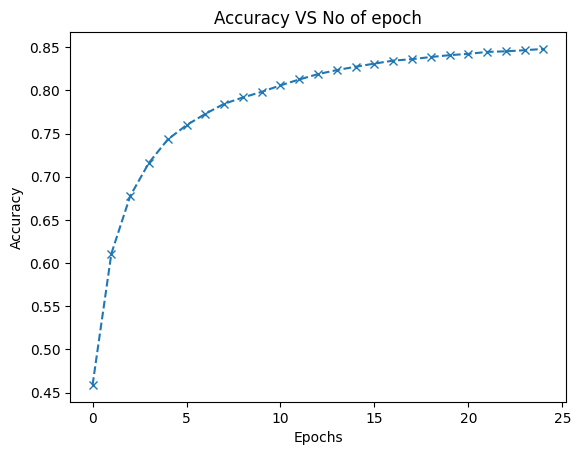

In [47]:
plt.title("Accuracy VS No of epoch")
plt.plot(accuracy , 'x--')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

In [48]:
test_dataset = MNIST(root = 'data/',train= False)

In [49]:
test_dataset = MNIST(root = 'data/',train= False , transform = transforms.ToTensor())

Label:  1


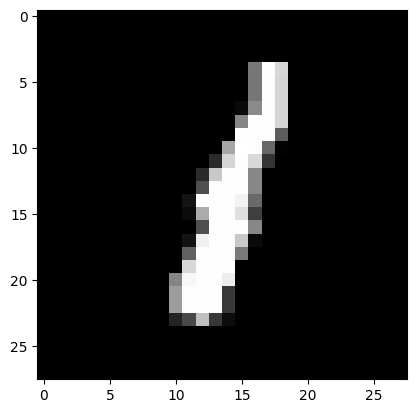

In [50]:
image , label = test_dataset[89]
plt.imshow(image[0],cmap = "gray")
print("Label: ",label)

In [51]:
def predict_image(img, model):
    xb = img.unsqueeze(0)
    yb = model(xb)
    _, preds = torch.max(yb , dim =1)
    return preds[0].item()

label :  7
predicted label:  7


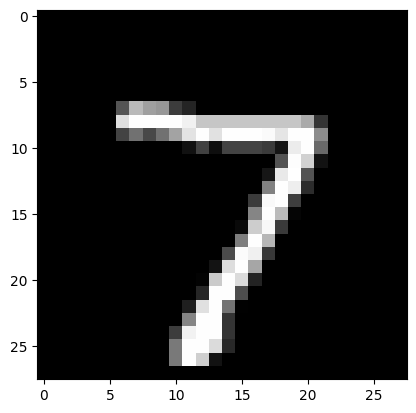

In [52]:
img , label = test_dataset[0]
plt.imshow(img[0], cmap = "grey")
print("label : ",label)
print("predicted label: ",predict_image(img , model))

label :  0
predicted label:  0


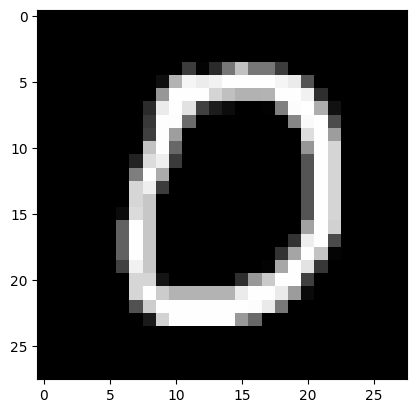

In [53]:
img , label = test_dataset[10]
plt.imshow(img[0], cmap = "grey")
print("label : ",label)
print("predicted label: ",predict_image(img , model))

label :  4
predicted label:  4


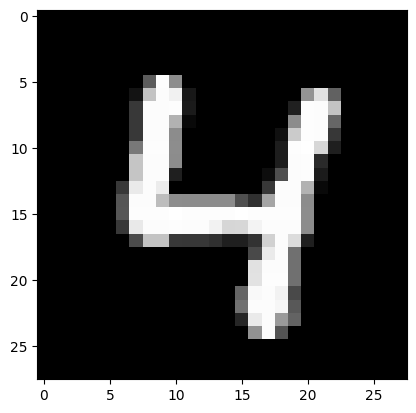

In [54]:
img , label = test_dataset[56]
plt.imshow(img[0], cmap = "grey")
print("label : ",label)
print("predicted label: ",predict_image(img , model))

label :  8
predicted label:  8


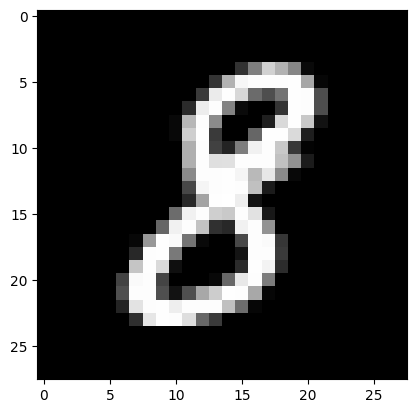

In [55]:
img , label = test_dataset[110]
plt.imshow(img[0], cmap = "grey")
print("label : ",label)
print("predicted label: ",predict_image(img , model))

In [56]:
img , label = test_dataset[0]
print(img.shape)

torch.Size([1, 28, 28])


In [57]:
test_loader = DataLoader(test_dataset ,batch_size = 128)

In [58]:
img , label = test_dataset[0]
print(img.shape)

torch.Size([1, 28, 28])


In [ ]:
result0 = evaluate(model , test_loader)
print(result0)

In [60]:
torch.save(model.state_dict(),"mnist-logistic.pth")

In [61]:
model.state_dict()

OrderedDict([('linear.weight',
              tensor([[ 0.0259,  0.0346,  0.0214,  ..., -0.0250, -0.0141, -0.0335],
                      [ 0.0159,  0.0201,  0.0348,  ...,  0.0064, -0.0175, -0.0345],
                      [ 0.0230, -0.0344, -0.0188,  ...,  0.0181, -0.0114,  0.0063],
                      ...,
                      [-0.0331,  0.0353,  0.0144,  ...,  0.0296, -0.0310,  0.0132],
                      [-0.0314,  0.0274,  0.0198,  ...,  0.0121, -0.0186, -0.0246],
                      [-0.0026,  0.0088, -0.0101,  ...,  0.0107, -0.0048, -0.0245]])),
             ('linear.bias',
              tensor([-0.0500,  0.0989,  0.0093, -0.0519,  0.0307,  0.0414, -0.0370,  0.0191,
                      -0.0544, -0.0196]))])

In [62]:
model2 = MnistModel()
model2.state_dict()

OrderedDict([('linear.weight',
              tensor([[-0.0334, -0.0332, -0.0074,  ..., -0.0256,  0.0091, -0.0104],
                      [-0.0224,  0.0091,  0.0090,  ..., -0.0069, -0.0139, -0.0068],
                      [ 0.0284, -0.0207,  0.0210,  ..., -0.0215, -0.0025, -0.0356],
                      ...,
                      [ 0.0161, -0.0160,  0.0196,  ...,  0.0022,  0.0089, -0.0302],
                      [-0.0332,  0.0220, -0.0128,  ..., -0.0157, -0.0220, -0.0228],
                      [-0.0117,  0.0313, -0.0191,  ...,  0.0139,  0.0236,  0.0143]])),
             ('linear.bias',
              tensor([ 0.0252, -0.0313, -0.0201,  0.0177,  0.0198, -0.0355,  0.0030,  0.0317,
                      -0.0196, -0.0207]))])

In [63]:
model2.load_state_dict(torch.load("mnist-logistic.pth"))

<All keys matched successfully>

In [ ]:
test_loader = DataLoader(test_dataset , batch_size = 128)
result = evaluate(model2 , test_loader)
print(result)